# Post-Hoc Reasoning Results Visualization

This notebook creates visualizations for parse rates and steering success rates across different alpha values.

In [7]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import pandas as pd

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [8]:
# Configuration
CACHE_DIR = Path("cache/experiments")
MODELS = [
    "google/gemma-2-2b-it",
    "google/gemma-2-9b-it", 
    "Qwen/Qwen2.5-3B-Instruct",
    "Qwen/Qwen2.5-7B-Instruct",
    "microsoft/Phi-3-small-8k-instruct",
    "meta-llama/Llama-2-7b-chat-hf",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"
]
DATASETS = ["anachronisms", "logical_deduction", "social_chemistry", "sports_understanding"]

In [9]:
def load_steering_results(model_path, dataset):
    """Load all steering results for a given model and dataset."""
    results = defaultdict(list)
    
    # Find the experiment directory
    model_dir = CACHE_DIR / model_path.replace("/", "_") / dataset
    if not model_dir.exists():
        return results
    
    # Find the split directory (assuming first one found)
    split_dirs = list(model_dir.glob("split_*"))
    if not split_dirs:
        return results
    
    split_dir = split_dirs[0]
    
    # Find the hash directory
    hash_dirs = [d for d in split_dir.iterdir() if d.is_dir() and d.name not in ["data", "metadata", "probes", "steering"]]
    if not hash_dirs:
        return results
    
    hash_dir = hash_dirs[0]
    steering_dir = hash_dir / "steering"
    
    if not steering_dir.exists():
        return results
    
    # Load all steering result files
    for file_path in steering_dir.glob("*.pkl"):
        # Parse filename to get alpha and direction
        filename = file_path.stem
        parts = filename.split("_")
        
        if "alpha" in filename:
            # Find alpha value
            alpha_idx = parts.index("alpha") + 1
            alpha = float(parts[alpha_idx])
            
            # For alpha=0, determine direction from filename
            if alpha == 0:
                if "yes" in filename:
                    direction = "yes"
                elif "no" in filename:
                    direction = "no"
                else:
                    continue  # Skip if direction unclear
            else:
                # For non-zero alpha, determine by sign
                direction = "yes" if alpha > 0 else "no"
            
            # Load the results
            with open(file_path, "rb") as f:
                data = pickle.load(f)
                results[direction].append((abs(alpha), data))
    
    return results

In [10]:
def calculate_metrics(steering_data):
    """Calculate no parse rate and steering success rate from steering results."""
    if not steering_data:
        return 0.0, 0.0
    
    total = len(steering_data)
    valid_parses = sum(1 for item in steering_data if item.get('is_valid_parse', False))
    successes = sum(1 for item in steering_data if item.get('success', False))
    
    # No parse rate is 1 - parse rate
    no_parse_rate = 1 - (valid_parses / total) if total > 0 else 0.0
    # Success rate denominator is number of valid parses, not total
    success_rate = successes / valid_parses if valid_parses > 0 else 0.0
    
    return no_parse_rate, success_rate

In [11]:
def create_bar_plots(model, dataset, direction_data, direction="yes"):
    """Create bar plots for no parse rate and steering success rate."""
    if not direction_data:
        return None
    
    # Sort by alpha value
    direction_data.sort(key=lambda x: x[0])
    
    alphas = []
    no_parse_rates = []
    success_rates = []
    
    for alpha, data in direction_data:
        no_parse_rate, success_rate = calculate_metrics(data)
        alphas.append(alpha)
        no_parse_rates.append(no_parse_rate)
        success_rates.append(success_rate)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(alphas))
    width = 0.35
    
    # Create bars
    bars1 = ax.bar(x - width/2, no_parse_rates, width, label='No Parse Rate', alpha=0.8)
    bars2 = ax.bar(x + width/2, success_rates, width, label='Steering Success Rate', alpha=0.8)
    
    # Customize plot
    ax.set_xlabel('Alpha Value', fontsize=12)
    ax.set_ylabel('Rate', fontsize=12)
    ax.set_title(f'{model}\n{dataset} - {direction.upper()} Direction', fontsize=14, pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels([str(a) for a in alphas])
    ax.legend()
    ax.set_ylim(0, 1.1)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.2f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom',
                       fontsize=9)
    
    plt.tight_layout()
    return fig


Processing google/gemma-2-2b-it - anachronisms...


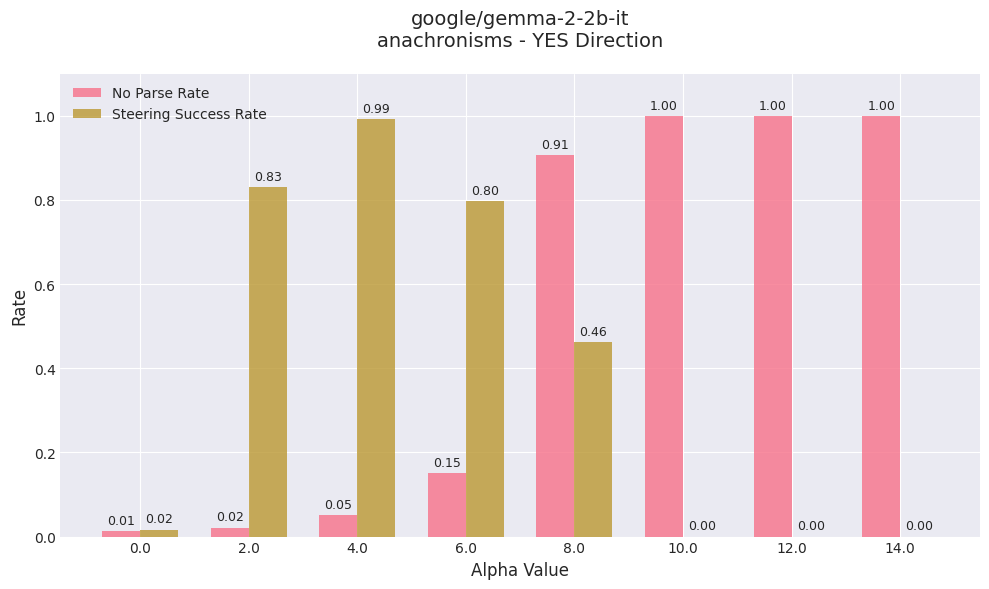

  Created yes direction plot


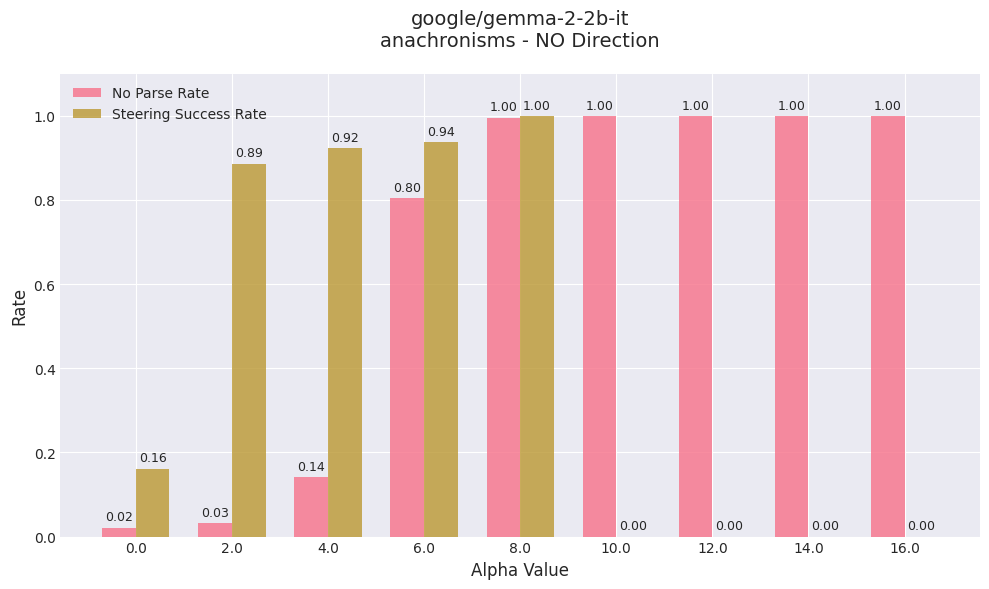

  Created no direction plot

Processing google/gemma-2-2b-it - logical_deduction...
  No steering results found

Processing google/gemma-2-2b-it - social_chemistry...
  No steering results found

Processing google/gemma-2-2b-it - sports_understanding...
  No steering results found

Processing google/gemma-2-9b-it - anachronisms...
  No steering results found

Processing google/gemma-2-9b-it - logical_deduction...
  No steering results found

Processing google/gemma-2-9b-it - social_chemistry...
  No steering results found

Processing google/gemma-2-9b-it - sports_understanding...


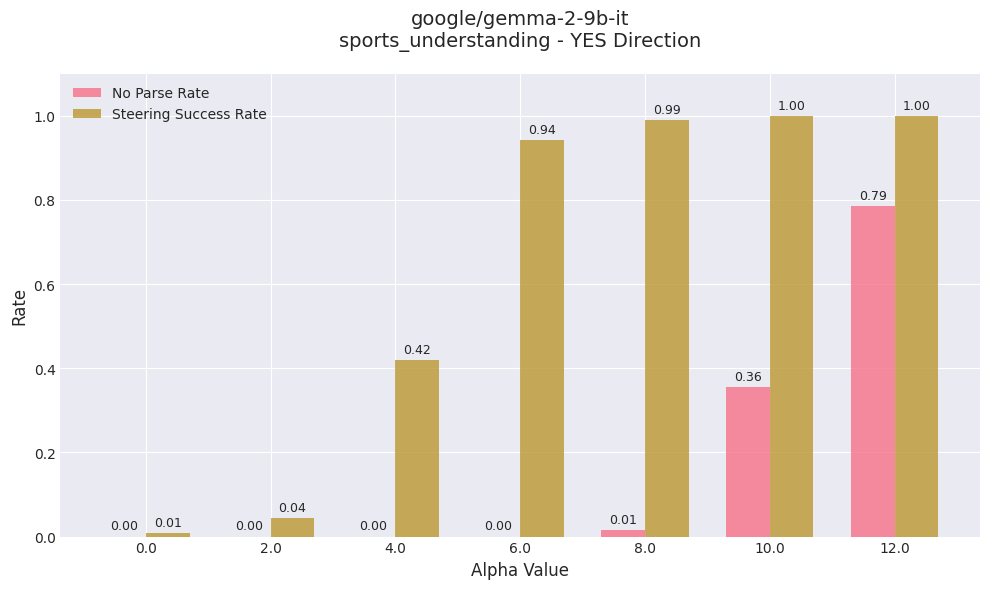

  Created yes direction plot


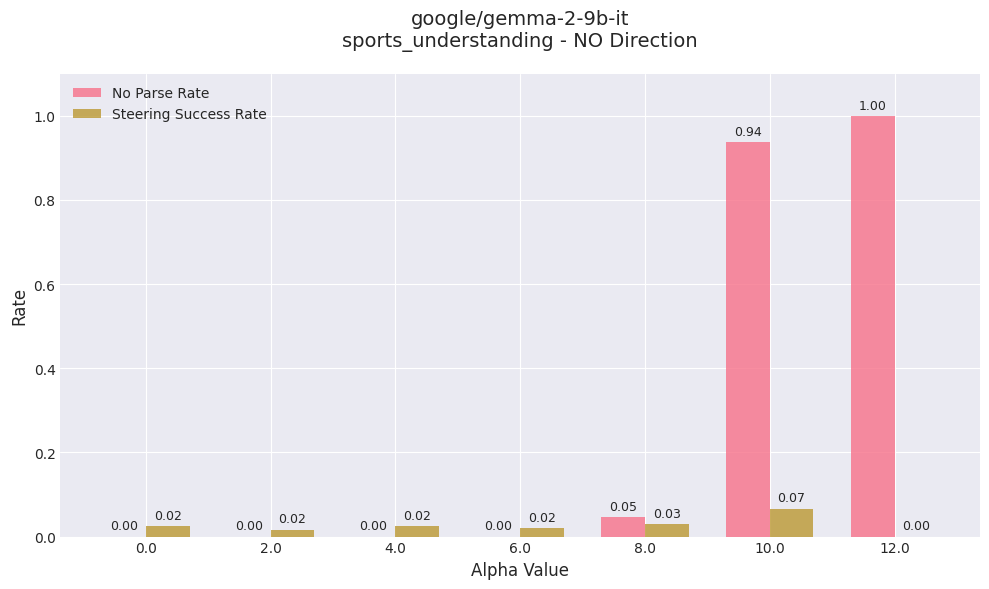

  Created no direction plot

Processing Qwen/Qwen2.5-3B-Instruct - anachronisms...
  No steering results found

Processing Qwen/Qwen2.5-3B-Instruct - logical_deduction...
  No steering results found

Processing Qwen/Qwen2.5-3B-Instruct - social_chemistry...
  No steering results found

Processing Qwen/Qwen2.5-3B-Instruct - sports_understanding...


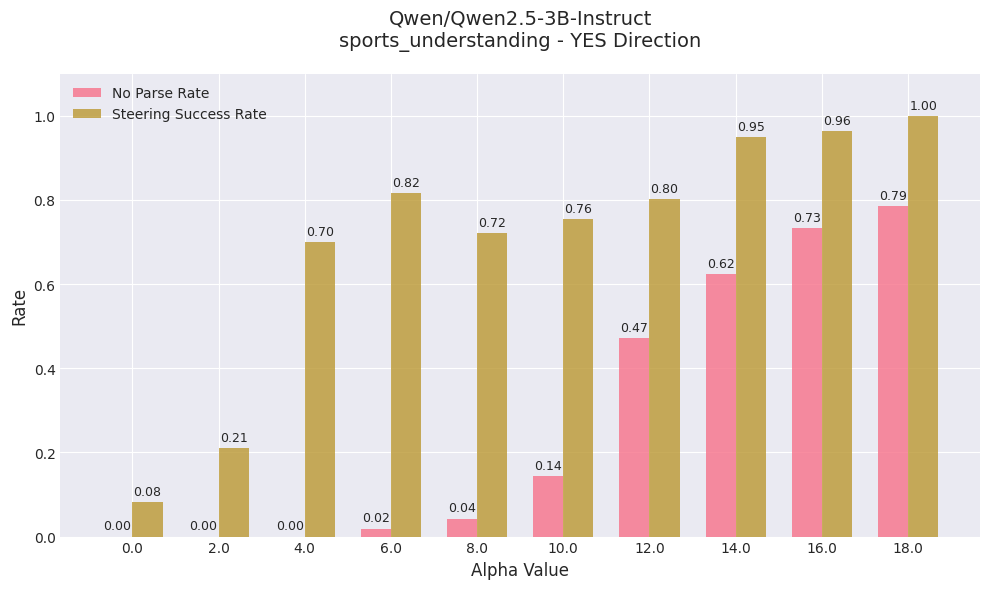

  Created yes direction plot


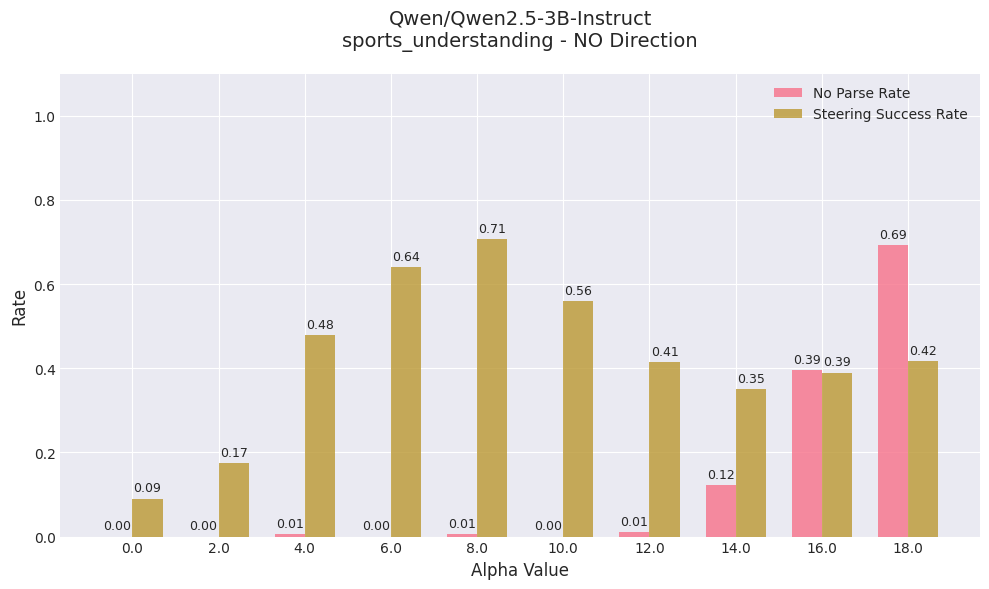

  Created no direction plot

Processing Qwen/Qwen2.5-7B-Instruct - anachronisms...
  No steering results found

Processing Qwen/Qwen2.5-7B-Instruct - logical_deduction...
  No steering results found

Processing Qwen/Qwen2.5-7B-Instruct - social_chemistry...
  No steering results found

Processing Qwen/Qwen2.5-7B-Instruct - sports_understanding...
  No steering results found

Processing microsoft/Phi-3-small-8k-instruct - anachronisms...
  No steering results found

Processing microsoft/Phi-3-small-8k-instruct - logical_deduction...
  No steering results found

Processing microsoft/Phi-3-small-8k-instruct - social_chemistry...
  No steering results found

Processing microsoft/Phi-3-small-8k-instruct - sports_understanding...
  No steering results found

Processing meta-llama/Llama-2-7b-chat-hf - anachronisms...
  No steering results found

Processing meta-llama/Llama-2-7b-chat-hf - logical_deduction...
  No steering results found

Processing meta-llama/Llama-2-7b-chat-hf - social_chemis

In [12]:
# Generate visualizations for all model-dataset combinations
all_figures = []

for model in MODELS:
    for dataset in DATASETS:
        print(f"\nProcessing {model} - {dataset}...")
        
        # Load steering results
        results = load_steering_results(model, dataset)
        
        if not results:
            print(f"  No steering results found")
            continue
        
        # Create plots for both directions
        for direction in ["yes", "no"]:
            if direction in results:
                fig = create_bar_plots(model, dataset, results[direction], direction)
                if fig:
                    all_figures.append((model, dataset, direction, fig))
                    plt.show()
                    print(f"  Created {direction} direction plot")
            else:
                print(f"  No {direction} direction data found")

In [51]:
# Save all figures to files
output_dir = Path("visualizations")
output_dir.mkdir(exist_ok=True)

for model, dataset, direction, fig in all_figures:
    filename = f"{model.replace('/', '_')}_{dataset}_{direction}.png"
    filepath = output_dir / filename
    fig.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"Saved: {filepath}")

Saved: visualizations/google_gemma-2-2b-it_anachronisms_yes.png
Saved: visualizations/google_gemma-2-2b-it_anachronisms_no.png
Saved: visualizations/google_gemma-2-2b-it_logical_deduction_yes.png
Saved: visualizations/google_gemma-2-2b-it_logical_deduction_no.png
Saved: visualizations/google_gemma-2-2b-it_social_chemistry_yes.png
Saved: visualizations/google_gemma-2-2b-it_social_chemistry_no.png
Saved: visualizations/google_gemma-2-2b-it_sports_understanding_yes.png


Saved: visualizations/google_gemma-2-2b-it_sports_understanding_no.png
Saved: visualizations/Qwen_Qwen2.5-3B-Instruct_logical_deduction_yes.png
Saved: visualizations/Qwen_Qwen2.5-3B-Instruct_logical_deduction_no.png
Saved: visualizations/Qwen_Qwen2.5-3B-Instruct_social_chemistry_yes.png
Saved: visualizations/Qwen_Qwen2.5-3B-Instruct_social_chemistry_no.png
Saved: visualizations/Qwen_Qwen2.5-3B-Instruct_sports_understanding_yes.png
Saved: visualizations/Qwen_Qwen2.5-3B-Instruct_sports_understanding_no.png
Saved: visualizations/Qwen_Qwen2.5-7B-Instruct_anachronisms_yes.png
Saved: visualizations/Qwen_Qwen2.5-7B-Instruct_anachronisms_no.png


In [52]:
# Create summary statistics
summary_data = []

for model in MODELS:
    for dataset in DATASETS:
        results = load_steering_results(model, dataset)
        
        if results:
            for direction in ["yes", "no"]:
                if direction in results:
                    for alpha, data in results[direction]:
                        no_parse_rate, success_rate = calculate_metrics(data)
                        summary_data.append({
                            'Model': model.split('/')[-1],
                            'Dataset': dataset,
                            'Direction': direction,
                            'Alpha': alpha,
                            'No Parse Rate': no_parse_rate,
                            'Success Rate': success_rate
                        })

# Create DataFrame and display summary
if summary_data:
    df = pd.DataFrame(summary_data)
    print("\nSummary Statistics:")
    print(df.groupby(['Model', 'Dataset', 'Direction'])[['No Parse Rate', 'Success Rate']].agg(['mean', 'std', 'max']))


Summary Statistics:
                                                   No Parse Rate            \
                                                            mean       std   
Model               Dataset              Direction                           
Qwen2.5-3B-Instruct logical_deduction    no             0.181818  0.266752   
                                         yes            0.069421  0.099526   
                    social_chemistry     no             0.606880  0.483529   
                                         yes            0.659091  0.442361   
                    sports_understanding no             0.110251  0.161707   
                                         yes            0.083333  0.175242   
Qwen2.5-7B-Instruct anachronisms         no             0.814471  0.398085   
                                         yes            0.727586  0.445007   
gemma-2-2b-it       anachronisms         no             0.734007  0.421610   
                                         ye

# Probe AUC Visualization Section

In [53]:
def load_auc_scores(model_path, dataset):
    """Load AUC scores for a given model and dataset."""
    # Find the experiment directory
    model_dir = CACHE_DIR / model_path.replace("/", "_") / dataset
    if not model_dir.exists():
        return None
    
    # Find the split directory
    split_dirs = list(model_dir.glob("split_*"))
    if not split_dirs:
        return None
    
    split_dir = split_dirs[0]
    
    # Find the hash directory
    hash_dirs = [d for d in split_dir.iterdir() if d.is_dir() and d.name not in ["data", "metadata", "probes", "steering"]]
    if not hash_dirs:
        return None
    
    hash_dir = hash_dirs[0]
    auc_file = hash_dir / "probes" / "auc_scores.json"
    
    if not auc_file.exists():
        return None
    
    with open(auc_file, "r") as f:
        return json.load(f)

In [54]:
# Collect all AUC data
auc_data = []

for model in MODELS:
    for dataset in DATASETS:
        auc_scores = load_auc_scores(model, dataset)
        if auc_scores:
            # AUC scores are stored as a list of floats (one per layer)
            if isinstance(auc_scores, list) and len(auc_scores) > 0:
                # Find best AUC and its layer index
                best_auc = max(auc_scores)
                best_layer = auc_scores.index(best_auc)
                
                auc_data.append({
                    'Model': model,
                    'Model_Short': model.split('/')[-1],
                    'Dataset': dataset,
                    'Best_AUC': best_auc,
                    'Best_Layer': best_layer
                })
            elif isinstance(auc_scores, dict):
                # Handle dictionary format if it exists
                if 'best_auc' in auc_scores:
                    best_auc = auc_scores['best_auc']
                    best_layer = auc_scores.get('best_layer', 'Unknown')
                else:
                    # Find best AUC from layer scores
                    layer_scores = {k: v for k, v in auc_scores.items() if k.startswith('layer_')}
                    if layer_scores:
                        best_layer = max(layer_scores, key=layer_scores.get)
                        best_auc = layer_scores[best_layer]
                        best_layer = best_layer.replace('layer_', '')
                    else:
                        continue
                
                auc_data.append({
                    'Model': model,
                    'Model_Short': model.split('/')[-1],
                    'Dataset': dataset,
                    'Best_AUC': best_auc,
                    'Best_Layer': best_layer
                })

# Create DataFrame
auc_df = pd.DataFrame(auc_data)
print(f"Found AUC data for {len(auc_df)} model-dataset combinations")

Found AUC data for 8 model-dataset combinations


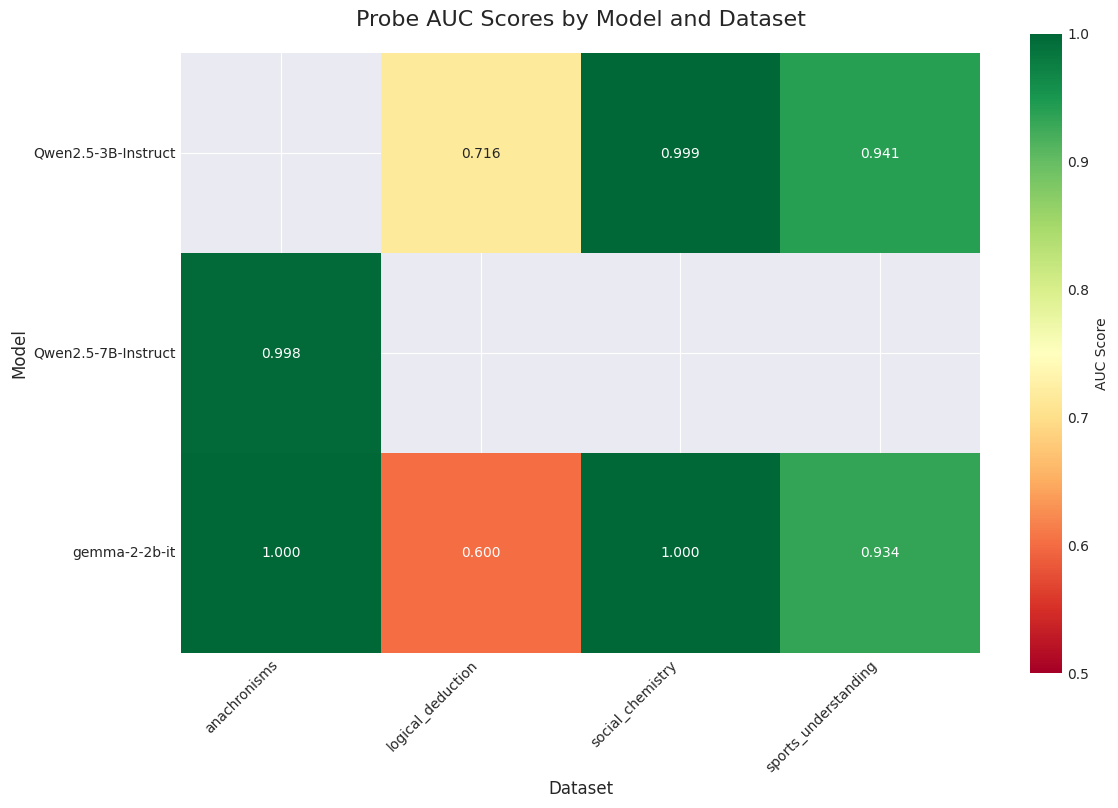

Saved AUC heatmap to visualizations/auc_heatmap.png


<Figure size 640x480 with 0 Axes>

In [55]:
# Create a heatmap of AUC scores
if not auc_df.empty:
    # Pivot the data for heatmap
    pivot_df = auc_df.pivot(index='Model_Short', columns='Dataset', values='Best_AUC')
    
    # Create figure
    plt.figure(figsize=(12, 8))
    
    # Create heatmap
    sns.heatmap(pivot_df, 
                annot=True, 
                fmt='.3f', 
                cmap='RdYlGn', 
                vmin=0.5, 
                vmax=1.0,
                cbar_kws={'label': 'AUC Score'},
                square=True)
    
    plt.title('Probe AUC Scores by Model and Dataset', fontsize=16, pad=20)
    plt.xlabel('Dataset', fontsize=12)
    plt.ylabel('Model', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Save the heatmap
    plt.savefig('visualizations/auc_heatmap.png', dpi=300, bbox_inches='tight')
    print("Saved AUC heatmap to visualizations/auc_heatmap.png")

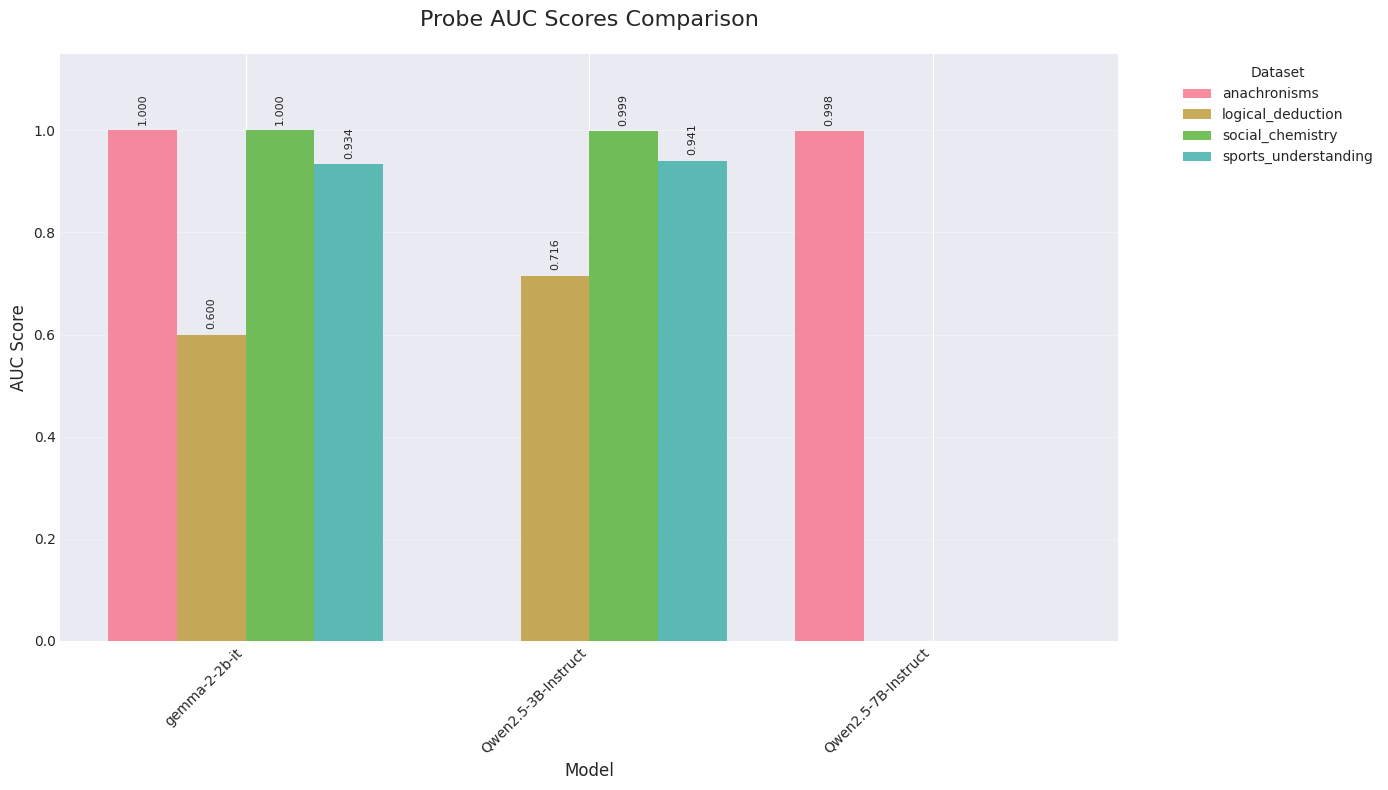

Saved AUC comparison bar chart to visualizations/auc_comparison_bars.png


<Figure size 640x480 with 0 Axes>

In [56]:
# Create bar chart comparing models across datasets
if not auc_df.empty:
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Get unique models and datasets
    models = auc_df['Model_Short'].unique()
    datasets = auc_df['Dataset'].unique()
    
    # Set up bar positions
    x = np.arange(len(models))
    width = 0.2
    offsets = np.linspace(-width*1.5, width*1.5, len(datasets))
    
    # Create bars for each dataset
    for i, dataset in enumerate(datasets):
        dataset_data = auc_df[auc_df['Dataset'] == dataset]
        values = []
        for model in models:
            model_data = dataset_data[dataset_data['Model_Short'] == model]
            if not model_data.empty:
                values.append(model_data['Best_AUC'].iloc[0])
            else:
                values.append(0)  # Missing data
        
        bars = ax.bar(x + offsets[i], values, width, label=dataset, alpha=0.8)
        
        # Add value labels
        for bar, value in zip(bars, values):
            if value > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                       f'{value:.3f}', ha='center', va='bottom', fontsize=8, rotation=90)
    
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('AUC Score', fontsize=12)
    ax.set_title('Probe AUC Scores Comparison', fontsize=16, pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_ylim(0, 1.15)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Save the bar chart
    plt.savefig('visualizations/auc_comparison_bars.png', dpi=300, bbox_inches='tight')
    print("Saved AUC comparison bar chart to visualizations/auc_comparison_bars.png")

In [57]:
# Display summary statistics for AUC scores
if not auc_df.empty:
    print("\nAUC Score Summary Statistics:")
    print("-" * 50)
    
    # Overall statistics
    print(f"\nOverall AUC: {auc_df['Best_AUC'].mean():.3f} ± {auc_df['Best_AUC'].std():.3f}")
    print(f"Best AUC: {auc_df['Best_AUC'].max():.3f}")
    print(f"Worst AUC: {auc_df['Best_AUC'].min():.3f}")
    
    # By model
    print("\nBy Model:")
    model_stats = auc_df.groupby('Model_Short')['Best_AUC'].agg(['mean', 'std', 'count'])
    for model, stats in model_stats.iterrows():
        print(f"  {model}: {stats['mean']:.3f} ± {stats['std']:.3f} (n={int(stats['count'])})")
    
    # By dataset
    print("\nBy Dataset:")
    dataset_stats = auc_df.groupby('Dataset')['Best_AUC'].agg(['mean', 'std', 'count'])
    for dataset, stats in dataset_stats.iterrows():
        print(f"  {dataset}: {stats['mean']:.3f} ± {stats['std']:.3f} (n={int(stats['count'])})")
    
    # Best performing model-dataset combinations
    print("\nTop 5 Model-Dataset Combinations:")
    top_combos = auc_df.nlargest(5, 'Best_AUC')[['Model_Short', 'Dataset', 'Best_AUC', 'Best_Layer']]
    for _, row in top_combos.iterrows():
        print(f"  {row['Model_Short']} - {row['Dataset']}: {row['Best_AUC']:.3f} (Layer {row['Best_Layer']})")


AUC Score Summary Statistics:
--------------------------------------------------

Overall AUC: 0.898 ± 0.154
Best AUC: 1.000
Worst AUC: 0.600

By Model:
  Qwen2.5-3B-Instruct: 0.885 ± 0.150 (n=3)
  Qwen2.5-7B-Instruct: 0.998 ± nan (n=1)
  gemma-2-2b-it: 0.883 ± 0.192 (n=4)

By Dataset:
  anachronisms: 0.999 ± 0.001 (n=2)
  logical_deduction: 0.658 ± 0.082 (n=2)
  social_chemistry: 1.000 ± 0.000 (n=2)
  sports_understanding: 0.937 ± 0.005 (n=2)

Top 5 Model-Dataset Combinations:
  gemma-2-2b-it - anachronisms: 1.000 (Layer 14)
  gemma-2-2b-it - social_chemistry: 1.000 (Layer 13)
  Qwen2.5-3B-Instruct - social_chemistry: 0.999 (Layer 27)
  Qwen2.5-7B-Instruct - anachronisms: 0.998 (Layer 18)
  Qwen2.5-3B-Instruct - sports_understanding: 0.941 (Layer 21)
